In [3]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.ar_model import AutoReg

In [4]:
end = dt.date.today()
start = end - dt.timedelta(days=365*5)
df = yf.download('GC=F', start = start, end = end )['Close']
df.rename(columns={'GC=F':'close'}, inplace=True)
df['returns'] = df['close'].pct_change()
df.dropna(inplace=True)

/tmp/ipykernel_31477/915223777.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GC=F', start = start, end = end )['Close']
[*********************100%***********************]  1 of 1 completed


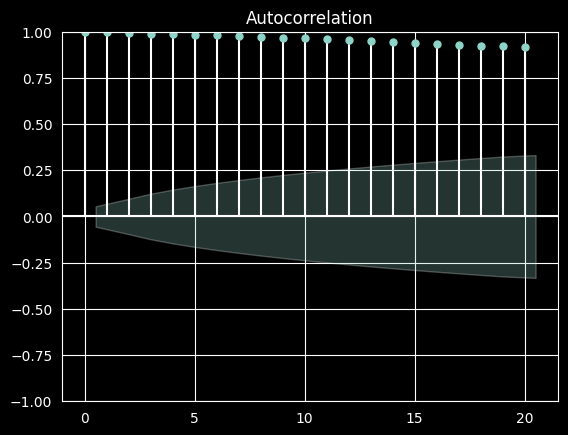

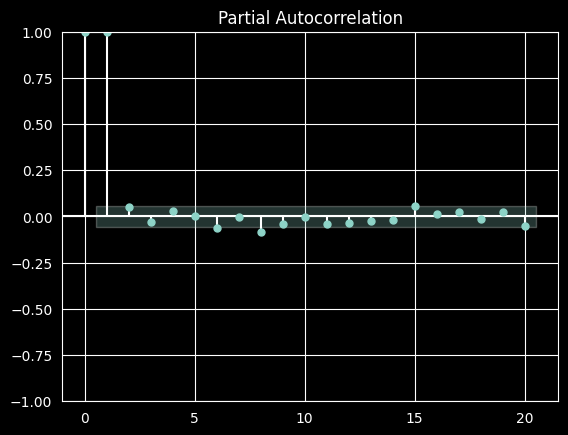

ADF Statistics: 1.487422248976067
p-value: 0.9974772516497292
KPS Statistics: 4.35341933946849
p-value: 0.01


/tmp/ipykernel_31477/438192353.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  results = kpss(df['close'],regression='c')


In [5]:
# ACF
plot_acf(df['close'], lags = 20)
plt.show()

# PACF
plot_pacf(df['close'], lags = 20)
plt.show()

# ADF

results = adfuller(df['close'])
print("ADF Statistics:", results[0])
print("p-value:", results[1])

# KKPS

results = kpss(df['close'],regression='c')
print("KPS Statistics:", results[0])
print("p-value:", results[1])

In [6]:
df

Ticker,close,returns
Date,,
2021-03-30,1683.900024,-0.016471
2021-03-31,1713.800049,0.017756
2021-04-01,1726.500000,0.007410
2021-04-05,1727.000000,0.000290
2021-04-06,1741.500000,0.008396
...,...,...
2026-03-23,4404.100098,-0.036386
2026-03-24,4399.299805,-0.001090
2026-03-25,4549.799805,0.034210


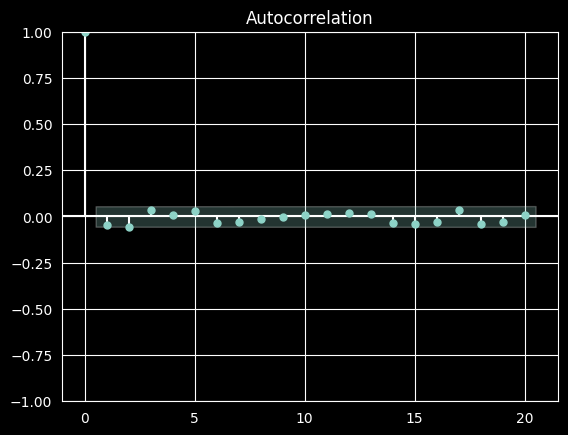

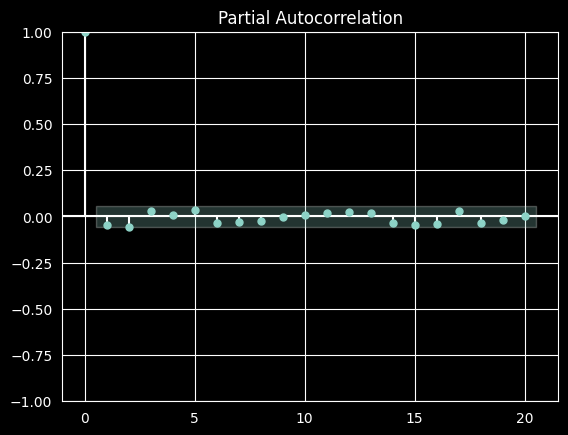

ADF Statistics: -27.091951336604808
p-value: 0.0
KPS Statistics: 0.3927887974735481
p-value: 0.08026344936484996


In [7]:
# ACF
plot_acf(df['returns'], lags = 20)
plt.show()

# PACF
plot_pacf(df['returns'], lags = 20)
plt.show()

# ADF

results = adfuller(df['returns'])
print("ADF Statistics:", results[0])
print("p-value:", results[1])

# KKPS

results = kpss(df['returns'],regression='c')
print("KPS Statistics:", results[0])
print("p-value:", results[1])

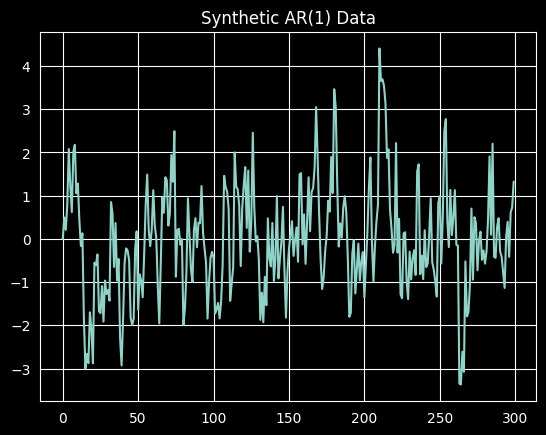

In [8]:
np.random.seed(42)  # for reproducibility

n = 300            # number of data points
phi = 0.7          # AR(1) coefficient

# create empty array
data = np.zeros(n)

# generate AR(1) process
for t in range(1, n):
    data[t] = phi * data[t-1] + np.random.normal(0, 1)

# convert to dataframe
df = pd.DataFrame(data, columns=['AR1'])

# plot
plt.plot(df['AR1'])
plt.title("Synthetic AR(1) Data")
plt.show()

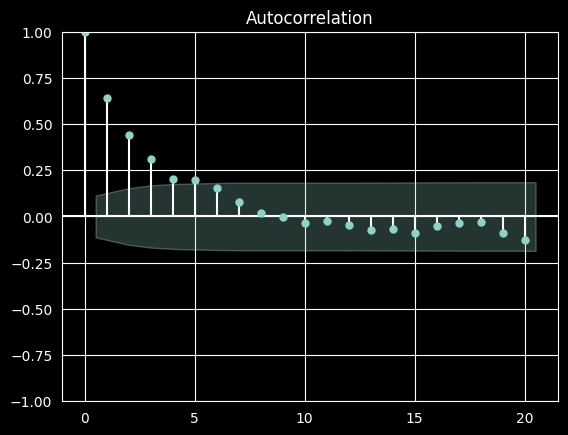

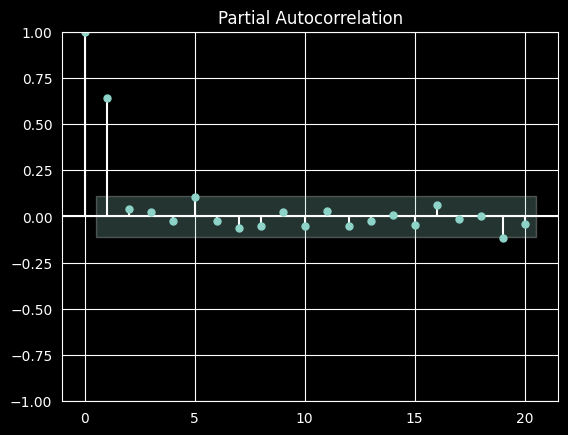

ADF Statistics: -7.968046603642533
p-value: 2.829928141173086e-12
KPS Statistics: 0.23909368342390402
p-value: 0.1


/tmp/ipykernel_31477/1270201514.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  results = kpss(df['AR1'],regression='c')


In [9]:
plot_acf(df['AR1'], lags = 20)
plt.show()

plot_pacf(df['AR1'], lags = 20)
plt.show()

results = adfuller(df['AR1'])
print("ADF Statistics:", results[0])
print("p-value:", results[1])

results = kpss(df['AR1'],regression='c')
print("KPS Statistics:", results[0])
print("p-value:", results[1])

In [10]:
model = AutoReg(df['AR1'], lags=1)
model_fit = model.fit()
print(model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                    AR1   No. Observations:                  300
Model:                     AutoReg(1)   Log Likelihood                -418.545
Method:               Conditional MLE   S.D. of innovations              0.981
Date:                Sat, 28 Mar 2026   AIC                            843.090
Time:                        21:02:32   BIC                            854.191
Sample:                             1   HQIC                           847.533
                                  300                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0099      0.057     -0.174      0.862      -0.121       0.101
AR1.L1         0.6459      0.044     14.581      0.000       0.559       0.733
                                    Roots           

In [15]:
# MultiVariate AR model
tickers = ['^NSEI', '^GSPC', '^INDIAVIX', 'GC=F', 'BZ=F', 'DX-Y.NYB']

df = yf.download(tickers, start=start, end=end)['Close']
df.columns = ['crude','dollar','gold','s&p','vix','nse']

/tmp/ipykernel_31477/4093060400.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start, end=end)['Close']
[*********************100%***********************]  6 of 6 completed


In [19]:
df[df.isna().any(axis=1)]

,crude,dollar,gold,s&p,vix,nse
Date,,,,,,
2021-03-29,64.980003,92.940002,1712.099976,3971.090088,NaN,NaN
2021-04-14,66.580002,91.690002,1734.900024,4124.660156,NaN,NaN
2021-04-21,65.320000,91.160004,1792.300049,4173.419922,NaN,NaN
2021-05-05,68.959999,91.309998,1784.099976,4167.589844,NaN,14617.849609
2021-05-11,68.550003,90.139999,1835.900024,4152.100098,NaN,14850.750000
...,...,...,...,...,...,...
2026-01-19,NaN,NaN,NaN,NaN,11.83,25585.500000
2026-01-26,65.589996,97.040001,5079.700195,6950.229980,NaN,NaN
2026-02-16,NaN,NaN,NaN,NaN,13.33,25682.750000


In [21]:
df = df.dropna(axis=0, how='any')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1189 entries, 2021-03-30 to 2026-03-27
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   crude   1189 non-null   float64
 1   dollar  1189 non-null   float64
 2   gold    1189 non-null   float64
 3   s&p     1189 non-null   float64
 4   vix     1189 non-null   float64
 5   nse     1189 non-null   float64
dtypes: float64(6)
memory usage: 65.0 KB


In [25]:
df

,crude,dollar,gold,s&p,vix,nse
Date,,,,,,
2021-03-30,64.139999,93.300003,1683.900024,3958.550049,20.490000,14845.099609
2021-03-31,63.540001,93.230003,1713.800049,3972.889893,20.650000,14690.700195
2021-04-01,64.860001,92.930000,1726.500000,4019.870117,19.990000,14867.349609
2021-04-05,62.150002,92.599998,1727.000000,4077.909912,21.219999,14637.799805
2021-04-06,62.740002,92.339996,1741.500000,4073.939941,20.840000,14683.500000
...,...,...,...,...,...,...
2026-03-20,112.190002,99.650002,4570.399902,6506.479980,22.809999,23114.500000
2026-03-23,99.940002,98.949997,4404.100098,6581.000000,26.730000,22512.650391
2026-03-24,104.489998,99.430000,4399.299805,6556.370117,24.740000,22912.400391


In [28]:
r = df.copy()
r['crude'] = df['crude'].pct_change()
r['dollar'] = df['dollar'].pct_change()
r['gold'] = df['gold'].pct_change()
r['s&p'] = df['s&p'].pct_change()
r['vix'] = df['vix'].pct_change()
r['nse'] = df['nse'].pct_change()
r.dropna(inplace=True)

In [30]:
# ADF
for col in r.columns:
    result = adfuller(df[col])
    print(f"{col}: {result}")

# KPPS
for col in r.columns:
    result = adfuller(r[col])
    print(f"{col}: {result}")

crude: (np.float64(-1.772818678234624), np.float64(0.3940374977538278), 6, 1182, {'1%': np.float64(-3.4358944654892474), '5%': np.float64(-2.86398831702468), '10%': np.float64(-2.5680735334014733)}, np.float64(5010.999075920916))
dollar: (np.float64(-2.0524029965790542), np.float64(0.2640789593434622), 0, 1188, {'1%': np.float64(-3.4358664022823593), '5%': np.float64(-2.8639759363158124), '10%': np.float64(-2.5680669397963927)}, np.float64(1617.0944103067736))
gold: (np.float64(1.1862759735774242), np.float64(0.9958896779627103), 21, 1167, {'1%': np.float64(-3.4359658887882794), '5%': np.float64(-2.8640198264838013), '10%': np.float64(-2.5680903145043392)}, np.float64(11855.798182472676))
s&p: (np.float64(-0.4669943381956383), np.float64(0.8982979989093511), 4, 1184, {'1%': np.float64(-3.4358850794152054), '5%': np.float64(-2.8639841761618654), '10%': np.float64(-2.568071328096466)}, np.float64(12546.938756138334))
vix: (np.float64(-3.3471619531826304), np.float64(0.012897529612492884)